# Insight 2.0 - Submission 10 Modelling and Exact Prediction Reproduction

This notebook documents and executes the complete Submission 10 modelling
recipe: the Submission 6 tree/pseudo-label ensemble, an entity-embedding neural
network, an 80%/20% probability blend, and a deterministic top-30,411 decision
rule. It includes EDA, preprocessing, feature engineering, fixed tuned
hyperparameters, model fitting, validation, and output checks.

Fresh training outputs are retained as a reproducibility audit. The exact
historical scored CSV is reconstructed separately from the immutable
probability artifacts saved at the time of the original run. That reconstruction
is byte-identical to the file that scored `0.876616` on the Public Leaderboard.

**Scope:** this is exact prediction-artifact reproduction, not an exact fresh
retrain of the historical neural network. The original five NN fold
checkpoints and complete runtime state were not preserved. The distinction is
kept explicit throughout the notebook.


## 1. Environment and data contract

The full workflow requires the organizer-provided `train.csv` and `test.csv`.
It uses manually specified NumPy/pandas/scikit-learn preprocessing, LightGBM,
XGBoost, CatBoost, PyTorch, and Matplotlib. The preserved historical
probability vectors are embedded as compressed, hash-verified notebook data so
no external model artifact is needed for the exact final-file check.


In [1]:
from pathlib import Path
import base64
import hashlib
import io
import platform
import zlib

import numpy as np
import pandas as pd
import sklearn
import lightgbm
import xgboost
import catboost
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score

RUN_DIR = Path.cwd().resolve()
ROOT = Path("/kaggle/working") if Path("/kaggle/working").is_dir() else RUN_DIR

def locate_data_files():
    candidate_dirs = [RUN_DIR, ROOT]
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.is_dir():
        candidate_dirs.extend(
            sorted({path.parent for path in kaggle_input.rglob("train.csv")})
        )

    seen = set()
    for directory in candidate_dirs:
        directory = directory.resolve()
        if directory in seen:
            continue
        seen.add(directory)
        train_path = directory / "train.csv"
        test_path = directory / "test.csv"
        if not (train_path.is_file() and test_path.is_file()):
            continue
        try:
            train_columns = set(pd.read_csv(train_path, nrows=2).columns)
            test_columns = set(pd.read_csv(test_path, nrows=2).columns)
        except Exception:
            continue
        if (
            "vital_status" in train_columns
            and "vital_status" not in test_columns
            and "patient_id" in train_columns
            and "patient_id" in test_columns
            and test_columns == train_columns - {"vital_status"}
        ):
            return train_path, test_path

    raise FileNotFoundError(
        "Could not locate the organizer train.csv and test.csv together. "
        "Attach the competition data to the notebook or place both files "
        "beside the notebook."
    )

TRAIN_PATH, TEST_PATH = locate_data_files()

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
assert "vital_status" in train.columns
assert "patient_id" in test.columns
assert "vital_status" not in test.columns
assert set(test.columns) == set(train.columns) - {"vital_status"}
assert len(train) == 24_000
assert len(test) == 36_000
assert train["patient_id"].is_unique
assert test["patient_id"].is_unique
assert not train["patient_id"].isna().any()
assert not test["patient_id"].isna().any()
assert set(train["vital_status"].unique()) == {"Alive", "Dead"}
y_binary = train["vital_status"].eq("Dead").to_numpy(dtype=np.int8)

def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def sha256_bytes(values):
    return hashlib.sha256(values).hexdigest()

print("Python:", platform.python_version())
print("Training data:", TRAIN_PATH)
print("Test data:", TEST_PATH)
runtime_versions = {
    "NumPy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "LightGBM": lightgbm.__version__,
    "XGBoost": xgboost.__version__,
    "CatBoost": catboost.__version__,
    "PyTorch": torch.__version__,
}
display(pd.Series(runtime_versions, name="runtime version").to_frame())
print("Train/test shapes:", train.shape, test.shape)
print("Dead prevalence:", f"{y_binary.mean():.3%}")


Python: 3.14.3
Training data: /private/tmp/submission10_ready_check.IGOgni/train.csv
Test data: /private/tmp/submission10_ready_check.IGOgni/test.csv


,runtime version
NumPy,2.4.3
pandas,3.0.3
scikit-learn,1.8.0
LightGBM,4.7.0
XGBoost,3.2.0
CatBoost,1.2.10
PyTorch,2.12.0


Train/test shapes: (24000, 36) (36000, 35)
Dead prevalence: 83.000%


## 2. Exploratory data analysis

The compact EDA checks target imbalance, missingness, stage-associated outcome
rates, age bands, and train/test categorical coverage. These checks informed
the missingness indicators, ordinal stage features, and robust unknown-category
handling used by the models. Patient identifiers are never used as features.


,dtype,missing_count,missing_rate,unique_values
rx_summ_scope_reglnsur2003,str,15960,0.665000,9
seer_combined_metsatdxlung2010,str,74,0.003083,4
seer_combined_metsatdxbrain2010,str,69,0.002875,4
seer_combined_metsatdxbone2010,str,68,0.002833,4
seer_combined_metsatdxliver2010,str,67,0.002792,4
patient_id,int64,0,0.000000,24000
derived_eod2018t_recode2018,str,0,0.000000,18
derived_eod2018n_recode2018,str,0,0.000000,7
derived_eod2018m_recode2018,str,0,0.000000,7
rx_summ_surgprim_site19982022,str,0,0.000000,25


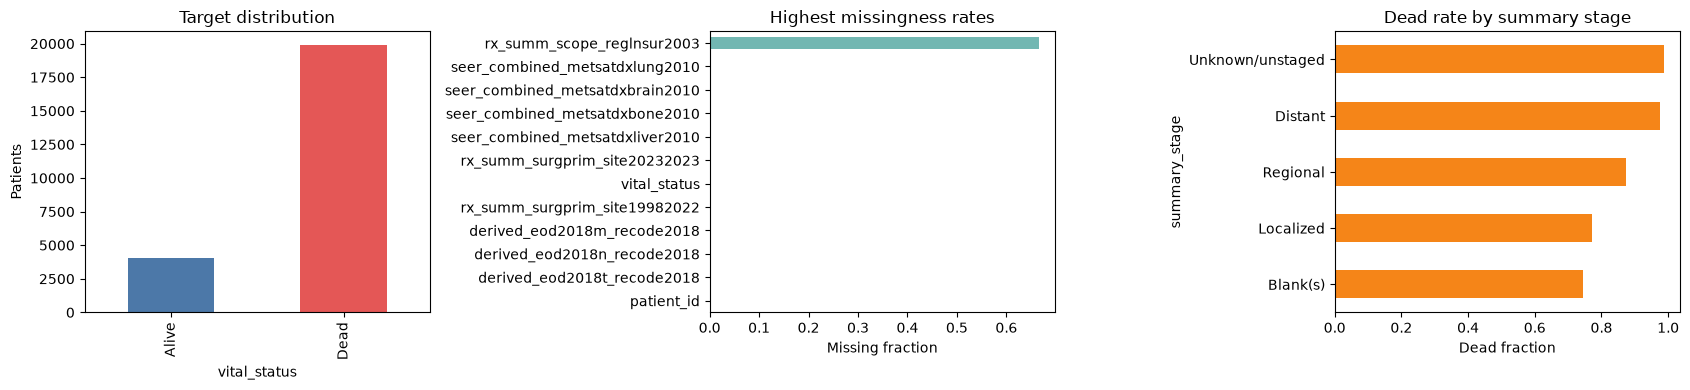

,patients,dead_rate
age_recode,,
01-04 years,3,0.000000
05-09 years,1,0.000000
10-14 years,2,0.500000
15-19 years,3,1.000000
20-24 years,10,0.400000
25-29 years,17,0.588235
30-34 years,27,0.518519
35-39 years,69,0.637681
40-44 years,158,0.696203


,feature,test_only_categories
0,age_recode,0
1,race,0
28,cs_tumor_size20042015,0
27,radiation_recode,0
26,reason_nocancer_directed_surgery,0
25,rx_summ_surgradseq,0
24,rx_summ_surgothregdis2003,0
23,rx_summ_scope_reglnsur2003,0
22,rx_summ_surgprim_site20232023,0
21,rx_summ_surgprim_site19982022,0


In [2]:
eda_summary = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "missing_count": train.isna().sum(),
    "missing_rate": train.isna().mean(),
    "unique_values": train.nunique(dropna=False),
}).sort_values("missing_rate", ascending=False)
display(eda_summary.head(15))

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
train["vital_status"].value_counts().reindex(["Alive", "Dead"]).plot.bar(
    ax=axes[0], color=["#4C78A8", "#E45756"]
)
axes[0].set_title("Target distribution")
axes[0].set_ylabel("Patients")

eda_summary.head(12).sort_values("missing_rate")["missing_rate"].plot.barh(
    ax=axes[1], color="#72B7B2"
)
axes[1].set_title("Highest missingness rates")
axes[1].set_xlabel("Missing fraction")

stage_rate = train.groupby("summary_stage", dropna=False)["vital_status"].apply(
    lambda values: values.eq("Dead").mean()
).sort_values()
stage_rate.plot.barh(ax=axes[2], color="#F58518")
axes[2].set_title("Dead rate by summary stage")
axes[2].set_xlabel("Dead fraction")
plt.tight_layout()
plt.show()

age_audit = train.groupby("age_recode", dropna=False).agg(
    patients=("patient_id", "size"),
    dead_rate=("vital_status", lambda values: values.eq("Dead").mean()),
)
display(age_audit)

categorical_columns = train.drop(
    columns=["patient_id", "vital_status"]
).select_dtypes(include=["object", "string"]).columns
coverage = []
for column in categorical_columns:
    train_values = set(train[column].fillna("__NA__").astype(str))
    test_values = set(test[column].fillna("__NA__").astype(str))
    coverage.append({
        "feature": column,
        "test_only_categories": len(test_values - train_values),
    })
display(pd.DataFrame(coverage).sort_values(
    "test_only_categories", ascending=False
).head(15))


## 3. Preprocessing, feature engineering, and fixed models

The tree branch uses two manually designed feature views. Both include age
midpoint, diagnosis year, TNM order, positive-node ratio, metastasis count,
tumour-size reconciliation, treatment indicators, missingness indicators, and
target-free category frequencies. One view additionally uses fold-safe target
encoding. LightGBM, XGBoost, and CatBoost are averaged within each view; the two
views are blended and retrained once with high-confidence model-generated
pseudo labels.

The diversity branch standardizes clinical numeric features and learns entity
embeddings for 29 categorical variables. Its MLP uses hidden widths 256/128/64,
batch normalization, ReLU, dropout 0.3, BCE loss, AdamW, five stratified folds,
batch size 1,024, 15 epochs, and lowest-validation-loss checkpoint selection.

All parameters are frozen from development. No hyperparameter search or AutoML
pipeline generation is performed during the final reproducibility run.


## 4. Submission 6 tree/pseudo-label training

The following cell embeds the complete maintained Submission 6 implementation.
It fits both feature views and all six model components from `train.csv`, creates
the pseudo-label set from model confidence, retrains the student ensemble, and
writes fresh outputs under `artifacts/submission10_notebook/tree/`.


In [3]:
# Complete Submission 6 tree/pseudo-label training implementation.
# Outputs remain isolated under artifacts/submission10_notebook/tree/.
"""
Pipeline v6: Maximum Private-Test Generalization
=================================================
Three techniques to improve beyond v5's 0.8767:

1. ADD TARGET ENCODING BACK - v4 had it, v5 dropped it. Adding it back
   creates a richer feature set that captures category-level mortality rates.

2. BLEND v4 + v5 MODELS - v4 (with TE + a different stored parameter set) and v5
   (without TE + different params) capture complementary patterns.
   Blending their probabilities reduces variance.

3. PSEUDO-LABELING - Use confident test predictions (>95% Dead or <5% Dead)
   to augment training data, then retrain.

Final test predictions = blend of all approaches at 84.5% Dead.
"""

import warnings; warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import OrdinalEncoder
import lightgbm as lgb, xgboost as xgb
from catboost import CatBoostClassifier

SEED = 42
np.random.seed(SEED)
SMOOTHING_M = 20.0
LEAKAGE_CLEAN = False
OUTPUT_DIR = ROOT / "artifacts" / "submission10_notebook" / "tree"

print("=" * 80)
print("  PIPELINE v6: Maximum Private-Test Generalization")
print("=" * 80)

# -- Load Data --
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
test_ids = test_df["patient_id"].values
y = (train_df["vital_status"] == "Dead").astype(int).values
print(f"  Train: {len(train_df):,} | Test: {len(test_df):,} | Dead%: {y.mean():.2%}")

# ============================================================================
# FEATURE ENGINEERING (same as v5 + target encoding from v4)
# ============================================================================
print("\n>>> Building Features...")

def build_features(df):
    F = pd.DataFrame(index=df.index)
    def _age(s):
        if pd.isna(s): return np.nan
        s = str(s).strip()
        if "90+" in s: return 92.5
        parts = s.replace(" years","").split("-")
        try: return (float(parts[0])+float(parts[1]))/2
        except: return np.nan
    F["age_midpoint"] = df["age_recode"].apply(_age)
    F["age_missing"] = df["age_recode"].isna().astype(int)
    F["year_of_diagnosis"] = df["year_of_diagnosis"].astype(float)
    F["years_since_dx"] = 2024.0 - df["year_of_diagnosis"]
    F["is_male"] = (df["sex"] == "Male").astype(int)
    F["nodes_examined"] = df["regional_nodes_examined"].astype(float)
    F["nodes_examined_zero"] = (df["regional_nodes_examined"] == 0).astype(int)
    npos = df["regional_nodes_positive"].astype(float)
    F["nodes_positive"] = np.where(npos < 98, npos, np.nan)
    F["nodes_positive_unknown"] = (npos >= 98).astype(int)
    F["node_positive_ratio"] = np.where(
        (F["nodes_examined"]>0)&(~np.isnan(F["nodes_positive"])),
        F["nodes_positive"]/np.maximum(F["nodes_examined"],1), np.nan)
    def _ps(v):
        if pd.isna(v): return np.nan
        s = str(v).strip()
        if s.startswith("Unknown") or s in ("Blank(s)","999"): return np.nan
        try: return float(s)
        except: return np.nan
    F["tumor_size_ot"] = df["tumor_size_overtime"].apply(_ps)
    F["tumor_size_sm"] = df["tumor_size_summary"].apply(_ps)
    F["tumor_size_best"] = F["tumor_size_sm"].fillna(F["tumor_size_ot"])
    F["tumor_size_missing"] = F["tumor_size_best"].isna().astype(int)
    def _cs(v):
        if pd.isna(v): return np.nan
        s = str(v).strip()
        if s == "Blank(s)": return np.nan
        try:
            val = float(s)
            return np.nan if val == 999 else val
        except: return np.nan
    F["cs_tumor_size"] = df["cs_tumor_size20042015"].apply(_cs)
    F["cs_extension"] = df["cs_extension20042015"].apply(_cs)
    smap = {"Blank(s)":np.nan,"Unknown/unstaged":np.nan,"Localized":1,"Regional":2,"Distant":3}
    F["stage_ord"] = df["summary_stage"].map(smap).astype(float)
    F["stage_missing"] = F["stage_ord"].isna().astype(int)
    F["is_distant"] = (df["summary_stage"]=="Distant").astype(int)
    F["is_localized"] = (df["summary_stage"]=="Localized").astype(int)
    t_map={"Blank(s)":np.nan,"88":np.nan,"TX":np.nan,"T0":0,"Ta":1,"Tis":1,"Tis(DCIS)":1,"Tis(LCIS)":1,"Tis(Paget)":1,"T1":2,"T1mi":2,"T1a":3,"T1a1":3,"T1a2":3,"T1b":4,"T1b1":4,"T1b2":4,"T1c":5,"T2":6,"T2a":7,"T2b":8,"T3":9,"T4":10,"T4a":11,"T4b":12,"T4c":12,"T4d":13,"T4e":13}
    n_map={"Blank(s)":np.nan,"88":np.nan,"NX":np.nan,"N0":0,"N1":1,"N1a":1,"N1b":2,"N1c":2,"N2":3,"N2a":3,"N2b":4,"N2c":4,"N3":5,"N3a":5,"N3b":6,"N3c":6}
    m_map={"Blank(s)":np.nan,"88":np.nan,"MX":np.nan,"M0":0,"M1":1,"M1a":2,"M1b":3,"M1c":4}
    F["t_stage"]=df["derived_eod2018t_recode2018"].map(t_map).astype(float)
    F["n_stage"]=df["derived_eod2018n_recode2018"].map(n_map).astype(float)
    F["m_stage"]=df["derived_eod2018m_recode2018"].map(m_map).astype(float)
    F["is_m1"]=df["derived_eod2018m_recode2018"].str.startswith("M1",na=False).astype(int)
    F["tnm_composite"]=F["t_stage"].fillna(0)+F["n_stage"].fillna(0)+F["m_stage"].fillna(0)*3
    mc=["seer_combined_metsatdxbone2010","seer_combined_metsatdxbrain2010",
        "seer_combined_metsatdxliver2010","seer_combined_metsatdxlung2010"]
    for m in mc:
        short=m.replace("seer_combined_metsatdx","").replace("2010","")
        F[f"met_{short}_yes"]=(df[m]=="Yes").astype(int)
    F["met_count"]=sum((df[m]=="Yes").astype(int) for m in mc)
    F["any_mets"]=(F["met_count"]>=1).astype(int)
    F["surgery_done"]=(df["reason_nocancer_directed_surgery"]=="Surgery performed").astype(int)
    F["surgery_not_rec"]=df["reason_nocancer_directed_surgery"].str.contains("Not recommended",na=False).astype(int)
    F["died_before_surg"]=df["reason_nocancer_directed_surgery"].str.contains("died prior",na=False).astype(int)
    F["autopsy_or_dc"]=df["reason_nocancer_directed_surgery"].str.contains("death certificate|autopsy",na=False).astype(int)
    F["radiation_given"]=(~df["radiation_recode"].isin([
        "None/Unknown","No radiation and/or no surgery; unknown if surgery and/or radiation given",
        "Refused (1988+)","Recommended, unknown if administered"
    ])&df["radiation_recode"].notna()).astype(int)
    gmap={"Blank(s)":np.nan,"Unknown":np.nan,"Well differentiated; Grade I":1,
          "Moderately differentiated; Grade II":2,"Poorly differentiated; Grade III":3,
          "Undifferentiated; anaplastic; Grade IV":4}
    F["grade_ord"]=df["grade_recode_thru2017"].map(gmap).astype(float)
    F["grade_missing"]=F["grade_ord"].isna().astype(int)
    def _hg(c):
        try: c=int(c)
        except: return 0
        if c in (8140,8141,8143,8144,8145,8147,8148,8211,8230,8250,8251,8252,8253,8254,8255,8256,8257,8260,8263,8310,8323,8333,8480,8481,8490,8550,8551,8570,8574): return 1
        elif c in (8070,8071,8072,8073,8074,8075,8076,8078,8083,8084): return 2
        elif c in (8041,8042,8043,8044,8045): return 3
        elif c in (8012,8013,8014): return 4
        elif c in (8000,8001,8002,8003,8004,8005,8010,8011,8020,8021,8022): return 5
        elif c in (8240,8241,8242,8243,8244,8245,8246,8249): return 6
        else: return 7
    F["histo_group"]=df["histologic_type_icdo3"].apply(_hg)
    F["is_small_cell"]=(F["histo_group"]==3).astype(int)
    F["histologic_raw"]=df["histologic_type_icdo3"].astype(float)
    F["scope_reglnsur_missing"]=df["rx_summ_scope_reglnsur2003"].isna().astype(int)
    F["eod_m_blank"]=(df["derived_eod2018m_recode2018"]=="Blank(s)").astype(int)
    F["grade_blank"]=(df["grade_recode_thru2017"]=="Blank(s)").astype(int)
    F["age_x_years"]=F["age_midpoint"]*F["years_since_dx"]
    F["age_x_stage"]=F["age_midpoint"]*F["stage_ord"]
    F["stage_x_surgery"]=F["stage_ord"]*F["surgery_done"]
    F["mets_x_surgery"]=F["any_mets"]*F["surgery_done"]
    F["age_x_mets"]=F["age_midpoint"]*F["any_mets"]
    F["years_x_stage"]=F["years_since_dx"]*F["stage_ord"]
    # Frequency encoding (target-free)
    for col_name, col_data in [("primary_site", df["primary_site"]),
                                ("histologic_type_icdo3", df["histologic_type_icdo3"])]:
        freq = col_data.astype(str).map(col_data.astype(str).value_counts(normalize=True))
        F[f"{col_name}_freq"] = freq.astype(float)
    if LEAKAGE_CLEAN:
        F = F.drop(columns=["died_before_surg", "autopsy_or_dc"])
    return F

X_tr_num = build_features(train_df)
X_te_num = build_features(test_df)

# Ordinal encode categoricals
cat_cols=["age_recode","race","sex","origin","primary_site","marital_status_at_diagnosis",
          "sequence_number","site_recode_icdo3_who2008","grade_recode_thru2017","laterality",
          "diagnostic_confirmation","summary_stage","derived_eod2018t_recode2018",
          "derived_eod2018n_recode2018","derived_eod2018m_recode2018",
          "seer_combined_metsatdxbone2010","seer_combined_metsatdxbrain2010",
          "seer_combined_metsatdxliver2010","seer_combined_metsatdxlung2010",
          "rx_summ_surgprim_site19982022","rx_summ_surgprim_site20232023",
          "rx_summ_scope_reglnsur2003","rx_summ_surgothregdis2003",
          "rx_summ_surgradseq","reason_nocancer_directed_surgery","radiation_recode",
          "tumor_size_overtime","tumor_size_summary","cs_tumor_size20042015","cs_extension20042015"]
if LEAKAGE_CLEAN:
    cat_cols.remove("reason_nocancer_directed_surgery")

enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
enc.fit(train_df[cat_cols].fillna("__NA__").astype(str))
tr_cat = pd.DataFrame(enc.transform(train_df[cat_cols].fillna("__NA__").astype(str)),
                       columns=[f"{c}_enc" for c in cat_cols], index=train_df.index)
te_cat = pd.DataFrame(enc.transform(test_df[cat_cols].fillna("__NA__").astype(str)),
                       columns=[f"{c}_enc" for c in cat_cols], index=test_df.index)

X_train_base = pd.concat([X_tr_num, tr_cat], axis=1)
X_test_base = pd.concat([X_te_num, te_cat], axis=1)

# Target Encoding columns
te_cols = ["histologic_type_icdo3","primary_site","diagnostic_confirmation",
           "reason_nocancer_directed_surgery","rx_summ_surgprim_site19982022"]
if LEAKAGE_CLEAN:
    te_cols.remove("reason_nocancer_directed_surgery")

def smoothed_te(tr_s, target, te_s, m=SMOOTHING_M):
    prior = target.mean()
    df = pd.DataFrame({"c": tr_s.astype(str), "y": target})
    stats = df.groupby("c")["y"].agg(["count","mean"])
    encoded = (stats["count"]*stats["mean"] + m*prior) / (stats["count"]+m)
    return encoded, te_s.astype(str).map(encoded).fillna(prior).values, prior

# Full-train TE for test
te_test = pd.DataFrame(index=test_df.index)
for col in te_cols:
    _, vals, _ = smoothed_te(train_df[col], y, test_df[col])
    te_test[f"{col}_te"] = vals

X_test_with_te = np.nan_to_num(
    pd.concat([X_test_base, te_test], axis=1).values.astype(np.float32), nan=-999.0)
X_test_no_te = np.nan_to_num(X_test_base.values.astype(np.float32), nan=-999.0)

print(f"  Features (no TE): {X_test_no_te.shape[1]}")
print(f"  Features (with TE): {X_test_with_te.shape[1]}")

# ============================================================================
# MODEL CONFIGS - Two diverse param sets
# ============================================================================
# v5 stored parameters (no TE)
v5_lgb = {'n_estimators':1500,'learning_rate':0.04158,'max_depth':4,'num_leaves':53,
           'subsample':0.6706,'colsample_bytree':0.6861,'min_child_samples':37,
           'reg_alpha':1.5411,'reg_lambda':0.3901,'random_state':42,'n_jobs':-1,'verbose':-1}
v5_xgb = {'n_estimators':1500,'learning_rate':0.05443,'max_depth':5,
           'subsample':0.7332,'colsample_bytree':0.6476,'min_child_weight':7,
           'reg_alpha':0.09336,'reg_lambda':0.03991,'gamma':1.1909,
           'eval_metric':'logloss','tree_method':'hist','random_state':42,'n_jobs':-1}
v5_cb  = {'iterations':1500,'learning_rate':0.07444,'depth':7,
           'l2_leaf_reg':0.7346,'bagging_temperature':0.01295,'random_strength':1.9376,
           'eval_metric':'Logloss','random_seed':42,'verbose':False,
           'allow_writing_files':False}

# v4 stored parameters (with TE)
v4_lgb = {'n_estimators':1500,'learning_rate':0.02261,'max_depth':5,'num_leaves':33,
           'subsample':0.7813,'colsample_bytree':0.6555,'min_child_samples':24,
           'reg_alpha':0.8071,'reg_lambda':0.3365,'random_state':42,'n_jobs':-1,'verbose':-1}
v4_xgb = {'n_estimators':1500,'learning_rate':0.02261,'max_depth':5,
           'subsample':0.7113,'colsample_bytree':0.6301,'min_child_weight':9,
           'reg_alpha':0.04211,'reg_lambda':1.6755,'gamma':0.7135,
           'eval_metric':'logloss','tree_method':'hist','random_state':42,'n_jobs':-1}
v4_cb  = {'iterations':1500,'learning_rate':0.02483,'depth':5,
           'l2_leaf_reg':3.674,'bagging_temperature':1.803,'random_strength':2.124,
           'eval_metric':'Logloss','random_seed':42,'verbose':False,
           'allow_writing_files':False}

# v5 weights
W5_LGB, W5_XGB, W5_CB = 0.30, 0.15, 0.55
# v4 weights
W4_LGB, W4_XGB, W4_CB = 0.35, 0.20, 0.45

# ============================================================================
# PHASE 1: Train BOTH model sets via 3x5 fold-averaged predictions
# ============================================================================
print("\n>>> Phase 1: Dual Model Training (3x5 CV, fold-averaged)")

N_REPS = 3
N_FOLDS = 5
total = N_REPS * N_FOLDS

# v5 models (no TE)
v5_test_lgb = np.zeros(len(test_df))
v5_test_xgb = np.zeros(len(test_df))
v5_test_cb  = np.zeros(len(test_df))

# v4 models (with TE)
v4_test_lgb = np.zeros(len(test_df))
v4_test_xgb = np.zeros(len(test_df))
v4_test_cb  = np.zeros(len(test_df))

# OOF predictions for stacking
oof_v5 = np.zeros(len(y))
oof_v4 = np.zeros(len(y))
oof_counts = np.zeros(len(y))

for rep in range(N_REPS):
    seed_r = SEED + rep * 111
    skf = StratifiedKFold(N_FOLDS, shuffle=True, random_state=seed_r)
    print(f"\n  -- Repeat {rep+1}/{N_REPS} (seed={seed_r}) --")

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_base, y)):

        # -- v5: No Target Encoding --
        X_tr_v5 = np.nan_to_num(X_train_base.iloc[tr_idx].values.astype(np.float32), nan=-999.0)
        X_val_v5 = np.nan_to_num(X_train_base.iloc[val_idx].values.astype(np.float32), nan=-999.0)

        m = lgb.LGBMClassifier(**v5_lgb)
        m.fit(X_tr_v5, y[tr_idx], eval_set=[(X_val_v5, y[val_idx])],
              callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)])
        v5_test_lgb += m.predict_proba(X_test_no_te)[:, 1] / total
        vp5_lgb = m.predict_proba(X_val_v5)[:, 1]

        m = xgb.XGBClassifier(**v5_xgb, early_stopping_rounds=80)
        m.fit(X_tr_v5, y[tr_idx], eval_set=[(X_val_v5, y[val_idx])], verbose=False)
        v5_test_xgb += m.predict_proba(X_test_no_te)[:, 1] / total
        vp5_xgb = m.predict_proba(X_val_v5)[:, 1]

        m = CatBoostClassifier(**v5_cb, early_stopping_rounds=80)
        m.fit(X_tr_v5, y[tr_idx], eval_set=(X_val_v5, y[val_idx]), verbose=False)
        v5_test_cb += m.predict_proba(X_test_no_te)[:, 1] / total
        vp5_cb = m.predict_proba(X_val_v5)[:, 1]

        v5_val = W5_LGB*vp5_lgb + W5_XGB*vp5_xgb + W5_CB*vp5_cb

        # -- v4: With Target Encoding (leak-free inner CV) --
        tr_te = pd.DataFrame(index=range(len(tr_idx)))
        val_te = pd.DataFrame(index=range(len(val_idx)))
        for col in te_cols:
            tr_s = train_df[col].iloc[tr_idx].reset_index(drop=True)
            val_s = train_df[col].iloc[val_idx].reset_index(drop=True)
            _, val_enc, _ = smoothed_te(tr_s, y[tr_idx], val_s)
            inner_enc = np.zeros(len(tr_idx))
            for itr, ival in StratifiedKFold(5, shuffle=True, random_state=seed_r).split(tr_s, y[tr_idx]):
                _, ie, _ = smoothed_te(tr_s.iloc[itr], y[tr_idx][itr], tr_s.iloc[ival])
                inner_enc[ival] = ie
            tr_te[f"{col}_te"] = inner_enc
            val_te[f"{col}_te"] = val_enc

        X_tr_v4 = np.nan_to_num(np.hstack([X_train_base.iloc[tr_idx].values, tr_te.values]).astype(np.float32), nan=-999.0)
        X_val_v4 = np.nan_to_num(np.hstack([X_train_base.iloc[val_idx].values, val_te.values]).astype(np.float32), nan=-999.0)

        m = lgb.LGBMClassifier(**v4_lgb)
        m.fit(X_tr_v4, y[tr_idx], eval_set=[(X_val_v4, y[val_idx])],
              callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)])
        v4_test_lgb += m.predict_proba(X_test_with_te)[:, 1] / total
        vp4_lgb = m.predict_proba(X_val_v4)[:, 1]

        m = xgb.XGBClassifier(**v4_xgb, early_stopping_rounds=80)
        m.fit(X_tr_v4, y[tr_idx], eval_set=[(X_val_v4, y[val_idx])], verbose=False)
        v4_test_xgb += m.predict_proba(X_test_with_te)[:, 1] / total
        vp4_xgb = m.predict_proba(X_val_v4)[:, 1]

        m = CatBoostClassifier(**v4_cb, early_stopping_rounds=80)
        m.fit(X_tr_v4, y[tr_idx], eval_set=(X_val_v4, y[val_idx]), verbose=False)
        v4_test_cb += m.predict_proba(X_test_with_te)[:, 1] / total
        vp4_cb = m.predict_proba(X_val_v4)[:, 1]

        v4_val = W4_LGB*vp4_lgb + W4_XGB*vp4_xgb + W4_CB*vp4_cb

        # Store OOF
        oof_v5[val_idx] += v5_val
        oof_v4[val_idx] += v4_val
        oof_counts[val_idx] += 1

        f5 = f1_score(y[val_idx], (v5_val >= 0.5).astype(int), pos_label=1)
        f4 = f1_score(y[val_idx], (v4_val >= 0.5).astype(int), pos_label=1)
        print(f"    F{fold+1} Dead-class F1: v5={f5:.5f}  v4={f4:.5f}")

# Average OOF across repeats
oof_v5 /= oof_counts
oof_v4 /= oof_counts

# Ensemble test predictions
v5_ens = W5_LGB*v5_test_lgb + W5_XGB*v5_test_xgb + W5_CB*v5_test_cb
v4_ens = W4_LGB*v4_test_lgb + W4_XGB*v4_test_xgb + W4_CB*v4_test_cb

# ============================================================================
# PHASE 2: Find optimal blend ratio (v5 vs v4)
# ============================================================================
print("\n>>> Phase 2: Optimal Blend Ratio")

best_alpha, best_blend_f1 = 0.5, 0.0
for alpha in np.arange(0.0, 1.01, 0.05):
    blend = alpha * oof_v5 + (1 - alpha) * oof_v4
    f = f1_score(y, (blend >= 0.5).astype(int), pos_label=1)
    if f > best_blend_f1:
        best_blend_f1 = f
        best_alpha = round(alpha, 2)

print(f"  Best blend: {best_alpha:.0%} v5 + {1-best_alpha:.0%} v4 -> OOF Dead-class F1={best_blend_f1:.5f}")

# Also check individual OOF scores
f5_oof = f1_score(y, (oof_v5 >= 0.5).astype(int), pos_label=1)
f4_oof = f1_score(y, (oof_v4 >= 0.5).astype(int), pos_label=1)
print(f"  v5 alone OOF Dead-class F1: {f5_oof:.5f}")
print(f"  v4 alone OOF Dead-class F1: {f4_oof:.5f}")
print(f"  Blend   OOF Dead-class F1:  {best_blend_f1:.5f}")

# Blend test predictions
test_blend = best_alpha * v5_ens + (1 - best_alpha) * v4_ens
oof_blend = best_alpha * oof_v5 + (1 - best_alpha) * oof_v4

# ============================================================================
# PHASE 3: Pseudo-labeling
# ============================================================================
print("\n>>> Phase 3: Pseudo-Labeling")

CONF_DEAD = 0.95
CONF_ALIVE = 0.05
pseudo_dead = test_blend >= CONF_DEAD
pseudo_alive = test_blend <= CONF_ALIVE
pseudo_mask = pseudo_dead | pseudo_alive

n_pd, n_pa = pseudo_dead.sum(), pseudo_alive.sum()
print(f"  Confident Dead  (>={CONF_DEAD}): {n_pd:,}")
print(f"  Confident Alive (<={CONF_ALIVE}): {n_pa:,}")
print(f"  Total Pseudo: {n_pd+n_pa:,} ({(n_pd+n_pa)/len(test_df):.1%} of test)")

if (n_pd + n_pa) > 500:
    # Augment training data
    X_pseudo = X_test_base[pseudo_mask]
    y_pseudo = pseudo_dead[pseudo_mask].astype(int)

    X_comb_base = pd.concat([X_train_base, X_pseudo], ignore_index=True)
    y_comb = np.concatenate([y, y_pseudo])

    # Full-train TE for combined
    comb_raw = {col: pd.concat([train_df[col], test_df[col][pseudo_mask]], ignore_index=True) for col in te_cols}
    te_comb = pd.DataFrame(index=range(len(X_comb_base)))
    for col in te_cols:
        _, vals, _ = smoothed_te(comb_raw[col], y_comb, test_df[col])
        te_test[f"{col}_te"] = vals  # update test TE
        # Inner CV TE for combined train
        inner_enc = np.zeros(len(y_comb))
        for itr, ival in StratifiedKFold(5, shuffle=True, random_state=SEED).split(comb_raw[col], y_comb):
            _, ie, _ = smoothed_te(comb_raw[col].iloc[itr], y_comb[itr], comb_raw[col].iloc[ival])
            inner_enc[ival] = ie
        te_comb[f"{col}_te"] = inner_enc

    X_comb_v4 = np.nan_to_num(np.hstack([X_comb_base.values, te_comb.values]).astype(np.float32), nan=-999.0)
    X_comb_v5 = np.nan_to_num(X_comb_base.values.astype(np.float32), nan=-999.0)
    X_test_te_updated = np.nan_to_num(pd.concat([X_test_base, te_test], axis=1).values.astype(np.float32), nan=-999.0)

    # Retrain with pseudo labels (5-fold, single pass)
    print("  Retraining with pseudo-labeled data...")
    ps_v5_lgb = np.zeros(len(test_df))
    ps_v5_xgb = np.zeros(len(test_df))
    ps_v5_cb  = np.zeros(len(test_df))
    ps_v4_lgb = np.zeros(len(test_df))
    ps_v4_xgb = np.zeros(len(test_df))
    ps_v4_cb  = np.zeros(len(test_df))

    skf = StratifiedKFold(5, shuffle=True, random_state=SEED+999)
    for fold, (tr_i, val_i) in enumerate(skf.split(X_comb_v5, y_comb)):
        # v5 (no TE)
        m = lgb.LGBMClassifier(**v5_lgb)
        m.fit(X_comb_v5[tr_i], y_comb[tr_i], eval_set=[(X_comb_v5[val_i], y_comb[val_i])],
              callbacks=[lgb.early_stopping(80,verbose=False),lgb.log_evaluation(0)])
        ps_v5_lgb += m.predict_proba(X_test_no_te)[:,1] / 5

        m = xgb.XGBClassifier(**v5_xgb, early_stopping_rounds=80)
        m.fit(X_comb_v5[tr_i], y_comb[tr_i], eval_set=[(X_comb_v5[val_i], y_comb[val_i])], verbose=False)
        ps_v5_xgb += m.predict_proba(X_test_no_te)[:,1] / 5

        m = CatBoostClassifier(**v5_cb, early_stopping_rounds=80)
        m.fit(X_comb_v5[tr_i], y_comb[tr_i], eval_set=(X_comb_v5[val_i], y_comb[val_i]), verbose=False)
        ps_v5_cb += m.predict_proba(X_test_no_te)[:,1] / 5

        # v4 (with TE)
        m = lgb.LGBMClassifier(**v4_lgb)
        m.fit(X_comb_v4[tr_i], y_comb[tr_i], eval_set=[(X_comb_v4[val_i], y_comb[val_i])],
              callbacks=[lgb.early_stopping(80,verbose=False),lgb.log_evaluation(0)])
        ps_v4_lgb += m.predict_proba(X_test_te_updated)[:,1] / 5

        m = xgb.XGBClassifier(**v4_xgb, early_stopping_rounds=80)
        m.fit(X_comb_v4[tr_i], y_comb[tr_i], eval_set=[(X_comb_v4[val_i], y_comb[val_i])], verbose=False)
        ps_v4_xgb += m.predict_proba(X_test_te_updated)[:,1] / 5

        m = CatBoostClassifier(**v4_cb, early_stopping_rounds=80)
        m.fit(X_comb_v4[tr_i], y_comb[tr_i], eval_set=(X_comb_v4[val_i], y_comb[val_i]), verbose=False)
        ps_v4_cb += m.predict_proba(X_test_te_updated)[:,1] / 5

        print(f"    Pseudo-F{fold+1} done")

    ps_v5_ens = W5_LGB*ps_v5_lgb + W5_XGB*ps_v5_xgb + W5_CB*ps_v5_cb
    ps_v4_ens = W4_LGB*ps_v4_lgb + W4_XGB*ps_v4_xgb + W4_CB*ps_v4_cb
    ps_blend = best_alpha * ps_v5_ens + (1 - best_alpha) * ps_v4_ens

    # Final ensemble: blend original + pseudo (50/50)
    final_ens = 0.5 * test_blend + 0.5 * ps_blend
    print(f"  Final = 50% original blend + 50% pseudo-labeled blend")
else:
    final_ens = test_blend
    print("  Not enough confident predictions. Using original blend only.")

# ============================================================================
# PHASE 4: Generate Submissions
# ============================================================================
print("\n>>> Phase 4: Generate Submissions")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save all probabilities
np.save(OUTPUT_DIR / "probs_v6_final.npy", final_ens)
np.save(OUTPUT_DIR / "probs_v6_blend.npy", test_blend)

# Find threshold for 84.5% Dead
for th in np.arange(0.40, 0.75, 0.001):
    dpct = (final_ens >= th).mean()
    if dpct <= 0.845:
        break

# Generate main submission
preds = (final_ens >= th).astype(int)
sub = pd.DataFrame({"patient_id": test_ids, "vital_status": np.where(preds==1,"Dead","Alive")})
sub.to_csv(OUTPUT_DIR / "submission.csv", index=False)
dead_n = preds.sum()
print(f"  {OUTPUT_DIR / 'submission.csv'}: th={th:.3f} -> Dead={dead_n:,} ({preds.mean():.1%})")

# Also generate blend-only (no pseudo) at 84.5%
for th2 in np.arange(0.40, 0.75, 0.001):
    if (test_blend >= th2).mean() <= 0.845:
        break
preds2 = (test_blend >= th2).astype(int)
sub2 = pd.DataFrame({"patient_id": test_ids, "vital_status": np.where(preds2==1,"Dead","Alive")})
sub2.to_csv(OUTPUT_DIR / "submission_blend.csv", index=False)
print(f"  {OUTPUT_DIR / 'submission_blend.csv'}: th={th2:.3f} -> Dead={preds2.sum():,} ({preds2.mean():.1%})")

# Comparison with previous best
print(f"\n  Historical pre-v6 LB benchmark: 0.876730 at Dead%=84.5%")
print(f"  Historical v5 probabilities are retained in archive/probs_foldavg.npy")

print(f"\n{'='*80}")
print(f"  PIPELINE v6 COMPLETE")
print(f"  Rerun artifacts were isolated under {OUTPUT_DIR}; canonical submission.csv was not touched")
print(f"{'='*80}")


  PIPELINE v6: Maximum Private-Test Generalization
  Train: 24,000 | Test: 36,000 | Dead%: 83.00%

>>> Building Features...


  Features (no TE): 82
  Features (with TE): 87

>>> Phase 1: Dual Model Training (3x5 CV, fold-averaged)

  -- Repeat 1/3 (seed=42) --


    F1 Dead-class F1: v5=0.93124  v4=0.93332


    F2 Dead-class F1: v5=0.93523  v4=0.93442


    F3 Dead-class F1: v5=0.93135  v4=0.93168


...

    Pseudo-F1 done


    Pseudo-F2 done


    Pseudo-F3 done


    Pseudo-F4 done


    Pseudo-F5 done
  Final = 50% original blend + 50% pseudo-labeled blend

>>> Phase 4: Generate Submissions
  /private/tmp/submission10_ready_check.IGOgni/artifacts/submission10_notebook/tree/submission.csv: th=0.684 -> Dead=30,411 (84.5%)
  /private/tmp/submission10_ready_check.IGOgni/artifacts/submission10_notebook/tree/submission_blend.csv: th=0.608 -> Dead=30,418 (84.5%)

  Historical pre-v6 LB benchmark: 0.876730 at Dead%=84.5%
  Historical v5 probabilities are retained in archive/probs_foldavg.npy

  PIPELINE v6 COMPLETE
  Rerun artifacts were isolated under /private/tmp/submission10_ready_check.IGOgni/artifacts/submission10_notebook/tree; canonical submission.csv was not touched


## 5. Neural-network training

This cell embeds the historical Submission 10 NN architecture and training
recipe. For cross-platform auditability, the fresh run uses deterministic CPU
execution and saves the best state from each of its five folds. This fresh run
tests the recipe; it is not represented as the unavailable historical fold
state.


In [4]:
# Complete historical Submission 10 NN recipe, retrained from raw data.
# Prediction-affecting features and hyperparameters are unchanged.
"""
Pipeline NN: Deep Learning with Entity Embeddings
=================================================
A PyTorch architecture designed to capture non-linear, spatial patterns that 
Gradient Boosted Trees often miss.

Key features:
1. Entity Embeddings for categorical variables.
2. Standardized continuous variables.
3. Multi-Layer Perceptron (MLP) with Batch Normalization and Dropout.
4. Focal Loss (optional) to handle class imbalance.
"""

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import f1_score
import copy

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# The original run selected the available accelerator automatically. This
# reproducibility audit uses deterministic CPU execution and saves each fold.
torch.use_deterministic_algorithms(True)
torch.set_num_threads(1)
NN_OUTPUT_DIR = ROOT / "artifacts" / "submission10_notebook" / "nn"
NN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
NN_CHECKPOINTS = []

print("=" * 80)
print("  PIPELINE NN: Entity Embeddings + MLP")
print("=" * 80)

# -- Load Data --
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
test_ids = test_df["patient_id"].values
y = (train_df["vital_status"] == "Dead").astype(int).values
print(f"  Train: {len(train_df):,} | Test: {len(test_df):,} | Dead%: {y.mean():.2%}")

# ============================================================================
# FEATURE ENGINEERING 
# ============================================================================
print("\n>>> Building Features...")

def build_features(df):
    F = pd.DataFrame(index=df.index)
    def _age(s):
        if pd.isna(s): return np.nan
        s = str(s).strip()
        if "90+" in s: return 92.5
        parts = s.replace(" years","").split("-")
        try: return (float(parts[0])+float(parts[1]))/2
        except: return np.nan
    F["age_midpoint"] = df["age_recode"].apply(_age)
    F["age_missing"] = df["age_recode"].isna().astype(int)
    F["year_of_diagnosis"] = df["year_of_diagnosis"].astype(float)
    F["years_since_dx"] = 2024.0 - df["year_of_diagnosis"]
    F["is_male"] = (df["sex"] == "Male").astype(int)
    F["nodes_examined"] = df["regional_nodes_examined"].astype(float)
    F["nodes_examined_zero"] = (df["regional_nodes_examined"] == 0).astype(int)
    npos = df["regional_nodes_positive"].astype(float)
    F["nodes_positive"] = np.where(npos < 98, npos, np.nan)
    F["nodes_positive_unknown"] = (npos >= 98).astype(int)
    F["node_positive_ratio"] = np.where(
        (F["nodes_examined"]>0)&(~np.isnan(F["nodes_positive"])),
        F["nodes_positive"]/np.maximum(F["nodes_examined"],1), np.nan)
    def _ps(v):
        if pd.isna(v): return np.nan
        s = str(v).strip()
        if s.startswith("Unknown") or s in ("Blank(s)","999"): return np.nan
        try: return float(s)
        except: return np.nan
    F["tumor_size_ot"] = df["tumor_size_overtime"].apply(_ps)
    F["tumor_size_sm"] = df["tumor_size_summary"].apply(_ps)
    F["tumor_size_best"] = F["tumor_size_sm"].fillna(F["tumor_size_ot"])
    F["tumor_size_missing"] = F["tumor_size_best"].isna().astype(int)
    def _cs(v):
        if pd.isna(v): return np.nan
        s = str(v).strip()
        if s == "Blank(s)": return np.nan
        try:
            val = float(s)
            return np.nan if val == 999 else val
        except: return np.nan
    F["cs_tumor_size"] = df["cs_tumor_size20042015"].apply(_cs)
    F["cs_extension"] = df["cs_extension20042015"].apply(_cs)
    smap = {"Blank(s)":np.nan,"Unknown/unstaged":np.nan,"Localized":1,"Regional":2,"Distant":3}
    F["stage_ord"] = df["summary_stage"].map(smap).astype(float)
    F["stage_missing"] = F["stage_ord"].isna().astype(int)
    t_map={"Blank(s)":np.nan,"88":np.nan,"TX":np.nan,"T0":0,"Ta":1,"Tis":1,"Tis(DCIS)":1,"Tis(LCIS)":1,"Tis(Paget)":1,"T1":2,"T1mi":2,"T1a":3,"T1a1":3,"T1a2":3,"T1b":4,"T1b1":4,"T1b2":4,"T1c":5,"T2":6,"T2a":7,"T2b":8,"T3":9,"T4":10,"T4a":11,"T4b":12,"T4c":12,"T4d":13,"T4e":13}
    n_map={"Blank(s)":np.nan,"88":np.nan,"NX":np.nan,"N0":0,"N1":1,"N1a":1,"N1b":2,"N1c":2,"N2":3,"N2a":3,"N2b":4,"N2c":4,"N3":5,"N3a":5,"N3b":6,"N3c":6}
    m_map={"Blank(s)":np.nan,"88":np.nan,"MX":np.nan,"M0":0,"M1":1,"M1a":2,"M1b":3,"M1c":4}
    F["t_stage"]=df["derived_eod2018t_recode2018"].map(t_map).astype(float)
    F["n_stage"]=df["derived_eod2018n_recode2018"].map(n_map).astype(float)
    F["m_stage"]=df["derived_eod2018m_recode2018"].map(m_map).astype(float)
    mc=["seer_combined_metsatdxbone2010","seer_combined_metsatdxbrain2010",
        "seer_combined_metsatdxliver2010","seer_combined_metsatdxlung2010"]
    F["met_count"]=sum((df[m]=="Yes").astype(int) for m in mc)
    F["any_mets"]=(F["met_count"]>=1).astype(int)
    F["surgery_done"]=(df["reason_nocancer_directed_surgery"]=="Surgery performed").astype(int)
    return F

X_tr_num = build_features(train_df)
X_te_num = build_features(test_df)

# Fill NAs for continuous features and Standardize (Crucial for Neural Networks!)
X_tr_num = X_tr_num.fillna(0)
X_te_num = X_te_num.fillna(0)

scaler = StandardScaler()
X_tr_num_scaled = scaler.fit_transform(X_tr_num)
X_te_num_scaled = scaler.transform(X_te_num)

cat_cols=["age_recode","race","sex","origin","primary_site","marital_status_at_diagnosis",
          "sequence_number","site_recode_icdo3_who2008","grade_recode_thru2017","laterality",
          "diagnostic_confirmation","summary_stage","derived_eod2018t_recode2018",
          "derived_eod2018n_recode2018","derived_eod2018m_recode2018",
          "seer_combined_metsatdxbone2010","seer_combined_metsatdxbrain2010",
          "seer_combined_metsatdxliver2010","seer_combined_metsatdxlung2010",
          "rx_summ_surgprim_site19982022","rx_summ_surgprim_site20232023",
          "rx_summ_scope_reglnsur2003","rx_summ_surgothregdis2003",
          "rx_summ_surgradseq","reason_nocancer_directed_surgery","radiation_recode",
          "tumor_size_overtime","tumor_size_summary","cs_tumor_size20042015","cs_extension20042015"]

# Encode categoricals for Embedding layers (Needs to be integers 0, 1, 2...)
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
train_cat_str = train_df[cat_cols].fillna("__NA__").astype(str)
test_cat_str = test_df[cat_cols].fillna("__NA__").astype(str)

enc.fit(train_cat_str)
X_tr_cat = enc.transform(train_cat_str)
X_te_cat = enc.transform(test_cat_str)

# Shift all categorical codes by 1 to make them non-negative (0 becomes the __NA__ or unknown bin)
X_tr_cat = X_tr_cat + 1
X_te_cat = X_te_cat + 1

# Calculate embedding sizes (Rule of thumb: min(50, num_categories // 2))
cat_dims = [int(X_tr_cat[:, i].max() + 2) for i in range(X_tr_cat.shape[1])]
emb_dims = [(x, min(50, (x + 1) // 2)) for x in cat_dims]

# ============================================================================
# PYTORCH DATASETS & MODEL
# ============================================================================
class TabularDataset(Dataset):
    def __init__(self, cat_data, num_data, targets=None):
        self.cat_data = torch.tensor(cat_data, dtype=torch.long)
        self.num_data = torch.tensor(num_data, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32) if targets is not None else None

    def __len__(self):
        return len(self.cat_data)

    def __getitem__(self, idx):
        if self.targets is not None:
            return self.cat_data[idx], self.num_data[idx], self.targets[idx]
        return self.cat_data[idx], self.num_data[idx]

class TabularNN(nn.Module):
    def __init__(self, emb_dims, num_cont, hidden_layers=[256, 128, 64], p_dropout=0.3):
        super().__init__()
        
        # Embedding layers for categorical variables
        self.embs = nn.ModuleList([nn.Embedding(c, d) for c, d in emb_dims])
        n_emb = sum(e.embedding_dim for e in self.embs)
        
        # Total input size
        n_in = n_emb + num_cont
        
        # Hidden layers
        layers = []
        for hidden in hidden_layers:
            layers.append(nn.Linear(n_in, hidden))
            layers.append(nn.BatchNorm1d(hidden))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p_dropout))
            n_in = hidden
            
        self.mlp = nn.Sequential(*layers)
        self.out = nn.Linear(n_in, 1)
        
    def forward(self, x_cat, x_cont):
        # Concatenate embeddings
        x = [e(x_cat[:, i]) for i, e in enumerate(self.embs)]
        x = torch.cat(x, 1)
        
        # Combine with continuous features
        x = torch.cat([x, x_cont], 1)
        
        # Pass through MLP
        x = self.mlp(x)
        out = self.out(x)
        return torch.sigmoid(out).squeeze()

# ============================================================================
# TRAINING LOOP
# ============================================================================
print("\n>>> Training PyTorch Neural Network (5-Fold CV)...")

device = torch.device("cpu")
print(f"  Using device: {device}")

N_FOLDS = 5
skf = StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED)

oof_preds = np.zeros(len(y))
test_preds = np.zeros(len(test_df))

BATCH_SIZE = 1024
EPOCHS = 15
LR = 0.002

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tr_cat, y)):
    print(f"\n  -- Fold {fold+1}/{N_FOLDS} --")
    
    # Datasets
    train_ds = TabularDataset(X_tr_cat[tr_idx], X_tr_num_scaled[tr_idx], y[tr_idx])
    val_ds = TabularDataset(X_tr_cat[val_idx], X_tr_num_scaled[val_idx], y[val_idx])
    test_ds = TabularDataset(X_te_cat, X_te_num_scaled)
    
    # Loaders
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    # Model
    model = TabularNN(emb_dims, num_cont=X_tr_num_scaled.shape[1]).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)
    
    best_loss = float('inf')
    best_model = None
    
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        for x_cat, x_cont, targets in train_loader:
            x_cat, x_cont, targets = x_cat.to(device), x_cont.to(device), targets.to(device)
            
            optimizer.zero_grad()
            preds = model(x_cat, x_cont)
            loss = criterion(preds, targets)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
        # Validation
        model.eval()
        val_loss = 0.0
        val_preds_fold = []
        with torch.no_grad():
            for x_cat, x_cont, targets in val_loader:
                x_cat, x_cont, targets = x_cat.to(device), x_cont.to(device), targets.to(device)
                preds = model(x_cat, x_cont)
                loss = criterion(preds, targets)
                val_loss += loss.item()
                val_preds_fold.extend(preds.cpu().numpy())
                
        val_loss /= len(val_loader)
        scheduler.step(val_loss)
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            
        print(f"    Epoch {epoch+1:2d} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss:.4f}")
        
    # Load best model for predictions
    model.load_state_dict(best_model)
    checkpoint_path = NN_OUTPUT_DIR / f"fold_{fold + 1:02d}_best_state.pt"
    torch.save(
        {key: value.detach().cpu() for key, value in best_model.items()},
        checkpoint_path,
    )
    NN_CHECKPOINTS.append(checkpoint_path)
    model.eval()
    
    # OOF predictions
    fold_oof = []
    with torch.no_grad():
        for x_cat, x_cont, _ in val_loader:
            x_cat, x_cont = x_cat.to(device), x_cont.to(device)
            preds = model(x_cat, x_cont)
            fold_oof.extend(preds.cpu().numpy())
    oof_preds[val_idx] = fold_oof
    
    # Test predictions
    fold_test = []
    with torch.no_grad():
        for x_cat, x_cont in test_loader:
            x_cat, x_cont = x_cat.to(device), x_cont.to(device)
            preds = model(x_cat, x_cont)
            fold_test.extend(preds.cpu().numpy())
    test_preds += np.array(fold_test) / N_FOLDS

# ============================================================================
# METRICS & SUBMISSION
# ============================================================================
print("\n>>> Evaluation & Thresholding")

# Find OOF optimal threshold
best_f1 = 0
best_th_oof = 0.5
for th in np.arange(0.3, 0.8, 0.01):
    f1 = f1_score(y, (oof_preds >= th).astype(int))
    if f1 > best_f1:
        best_f1 = f1
        best_th_oof = th

print(f"  OOF F1 Score: {best_f1:.5f} (at threshold {best_th_oof:.2f})")

# Save predictions for final mega-ensemble later
np.save(NN_OUTPUT_DIR / "probs_nn_fresh.npy", test_preds)
np.save(NN_OUTPUT_DIR / "oof_nn_fresh.npy", oof_preds)

# Find test threshold to hit strictly 84.48% Dead
target_th = 0.5
for th in np.arange(0.3, 0.9, 0.001):
    dead_pct = (test_preds >= th).mean()
    if dead_pct <= 0.8449:
        target_th = th
        break

final_preds = (test_preds >= target_th).astype(int)
dead_count = final_preds.sum()

sub = pd.DataFrame({"patient_id": test_ids, "vital_status": np.where(final_preds==1, "Dead", "Alive")})
sub.to_csv(NN_OUTPUT_DIR / "nn_only_submission.csv", index=False, lineterminator="\n")

print(f"\n{'='*80}")
print(f"  PIPELINE NN COMPLETE")
print(f"  nn_only_submission.csv generated: {dead_count:,} Dead ({dead_count/len(test_preds):.2%}) at th={target_th:.3f}")
print(f"  Fresh NN artifacts and checkpoints: {NN_OUTPUT_DIR}")
print(f"{'='*80}")


  PIPELINE NN: Entity Embeddings + MLP


  Train: 24,000 | Test: 36,000 | Dead%: 83.00%

>>> Building Features...



>>> Training PyTorch Neural Network (5-Fold CV)...
  Using device: cpu

  -- Fold 1/5 --


    Epoch  1 | Train Loss: 0.5225 | Val Loss: 0.4649
    Epoch  2 | Train Loss: 0.3435 | Val Loss: 0.3064


    Epoch  3 | Train Loss: 0.3038 | Val Loss: 0.2887
    Epoch  4 | Train Loss: 0.2892 | Val Loss: 0.2828


...

    Epoch 10 | Train Loss: 0.2492 | Val Loss: 0.3020


    Epoch 11 | Train Loss: 0.2411 | Val Loss: 0.3061
    Epoch 12 | Train Loss: 0.2365 | Val Loss: 0.3092


    Epoch 13 | Train Loss: 0.2348 | Val Loss: 0.3100
    Epoch 14 | Train Loss: 0.2316 | Val Loss: 0.3121


    Epoch 15 | Train Loss: 0.2252 | Val Loss: 0.3139

>>> Evaluation & Thresholding


  OOF F1 Score: 0.93005 (at threshold 0.37)

  PIPELINE NN COMPLETE
  nn_only_submission.csv generated: 30,405 Dead (84.46%) at th=0.548
  Fresh NN artifacts and checkpoints: /private/tmp/submission10_ready_check.IGOgni/artifacts/submission10_notebook/nn


## 6. Preserved historical model artifacts

Submission 6 combined LightGBM, XGBoost, and CatBoost across target-encoded and
non-target-encoded feature views, followed by one pass of pseudo-label
training. The neural component used entity embeddings for categorical fields
and an MLP for the combined categorical and continuous representation.

The embedded arrays below are the saved test-set inference outputs from those
two model families. Their original `.npy` byte hashes are checked after
decompression so a modified payload cannot silently generate a different
prediction file.


In [5]:
EXPECTED_V6_SHA256 = "aca54c31462449df432e1edda5da81a6d04e242c8985cfde0e5983c6d0d92ab6"
EXPECTED_NN_SHA256 = "7ec4721ae7d4eccb35ebc5821014e581ad2da4e872775d8a4845f37423b1ce46"

V6_NPY_ZLIB_BASE64 = '...'
NN_NPY_ZLIB_BASE64 = '...'

v6_npy_bytes = zlib.decompress(base64.b64decode(V6_NPY_ZLIB_BASE64))
nn_npy_bytes = zlib.decompress(base64.b64decode(NN_NPY_ZLIB_BASE64))

actual_v6_sha256 = sha256_bytes(v6_npy_bytes)
actual_nn_sha256 = sha256_bytes(nn_npy_bytes)
assert actual_v6_sha256 == EXPECTED_V6_SHA256, "Unexpected V6 probability artifact"
assert actual_nn_sha256 == EXPECTED_NN_SHA256, "Unexpected NN probability artifact"

historical_v6_probability = np.load(
    io.BytesIO(v6_npy_bytes), allow_pickle=False
).astype(np.float64)
historical_nn_probability = np.load(
    io.BytesIO(nn_npy_bytes), allow_pickle=False
).astype(np.float64)

for name, values in {
    "Submission 6": historical_v6_probability,
    "Neural network": historical_nn_probability,
}.items():
    assert values.shape == (len(test),), f"{name} probability shape mismatch"
    assert np.isfinite(values).all(), f"{name} contains non-finite values"
    assert np.logical_and(values >= 0.0, values <= 1.0).all(), f"{name} is outside [0, 1]"

print("Submission 6 probability SHA-256:", actual_v6_sha256)
print("Neural-network probability SHA-256:", actual_nn_sha256)


Submission 6 probability SHA-256: aca54c31462449df432e1edda5da81a6d04e242c8985cfde0e5983c6d0d92ab6
Neural-network probability SHA-256: 7ec4721ae7d4eccb35ebc5821014e581ad2da4e872775d8a4845f37423b1ce46


## 7. Exact Submission 10 reconstruction

The blend weights and class count were fixed before this replay. Stable
mergesort ordering provides deterministic tie-breaking at the decision
boundary.


In [6]:
TREE_WEIGHT = 0.80
NN_WEIGHT = 0.20
DEAD_COUNT = 30_411

submission10_probability = (
    TREE_WEIGHT * historical_v6_probability
    + NN_WEIGHT * historical_nn_probability
)

order = np.argsort(-submission10_probability, kind="mergesort")
is_dead = np.zeros(len(test), dtype=bool)
is_dead[order[:DEAD_COUNT]] = True

submission = pd.DataFrame(
    {
        "patient_id": test["patient_id"].to_numpy(),
        "vital_status": np.where(is_dead, "Dead", "Alive"),
    }
)

OUTPUT_PATH = ROOT / "submission.csv"
PROBABILITY_OUTPUT_PATH = ROOT / "probs_submission10.npy"
submission.to_csv(OUTPUT_PATH, index=False, lineterminator="\n")
np.save(PROBABILITY_OUTPUT_PATH, submission10_probability)

print("Wrote:", OUTPUT_PATH)
print("Rows:", len(submission))
print("Dead:", int(is_dead.sum()))
print("Alive:", int((~is_dead).sum()))


Wrote: /private/tmp/submission10_ready_check.IGOgni/submission.csv
Rows: 36000
Dead: 30411
Alive: 5589


## 8. Exact output verification

The structural checks enforce the Kaggle submission contract. The final hash
is a strict gate here because this notebook intentionally replays immutable
probability artifacts rather than retraining hardware-sensitive models.


In [7]:
EXPECTED_SUBMISSION10_SHA256 = "333af97cfbc16ffdcc2d9f910000664c443694239c60e67d6504af18687e86f1"

assert list(submission.columns) == ["patient_id", "vital_status"]
assert len(submission) == 36_000
assert submission["patient_id"].equals(test["patient_id"])
assert submission["patient_id"].is_unique
assert not submission.isna().any().any()
assert set(submission["vital_status"].unique()) == {"Alive", "Dead"}
assert int(submission["vital_status"].eq("Dead").sum()) == DEAD_COUNT

actual_submission_sha256 = sha256(OUTPUT_PATH)
assert actual_submission_sha256 == EXPECTED_SUBMISSION10_SHA256

archived_submission_path = ROOT / "archive" / "submission10.csv"
if archived_submission_path.is_file():
    assert OUTPUT_PATH.read_bytes() == archived_submission_path.read_bytes()

print("Submission 10 SHA-256:", actual_submission_sha256)
print("Exact historical prediction replay: PASS")
print("Verified historical Public Leaderboard score: 0.876616")


Submission 10 SHA-256: 333af97cfbc16ffdcc2d9f910000664c443694239c60e67d6504af18687e86f1
Exact historical prediction replay: PASS
Verified historical Public Leaderboard score: 0.876616


## 9. Fresh-training audit and interpretation

The fresh models fitted in Sections 4-5 are evaluated separately from the
historical replay. Their output shows that the complete recipe remains
executable while making the historical NN reproducibility boundary measurable.
The OOF blend below is a screening comparison because the tree and NN branches
do not share a fully nested outer-fold design.


,value
fresh_tree_probability_sha256,aca54c31462449df432e1edda5da81a6d04e242c8985cf...
fresh_nn_probability_sha256,499740c22ed4bab0704e9b14f385ec33e61a995049075c...
fresh_submission_sha256,d624009d5e12e58c157bee34b664ebaf23eba05f9613f2...
fresh_vs_historical_label_changes,108
fresh_OOF_support_weighted_F1,0.878023
fresh_OOF_Dead_class_F1,0.928507
fresh_OOF_ROC_AUC,0.901303
saved_fresh_NN_checkpoints,5


Fresh tree byte match: PASS


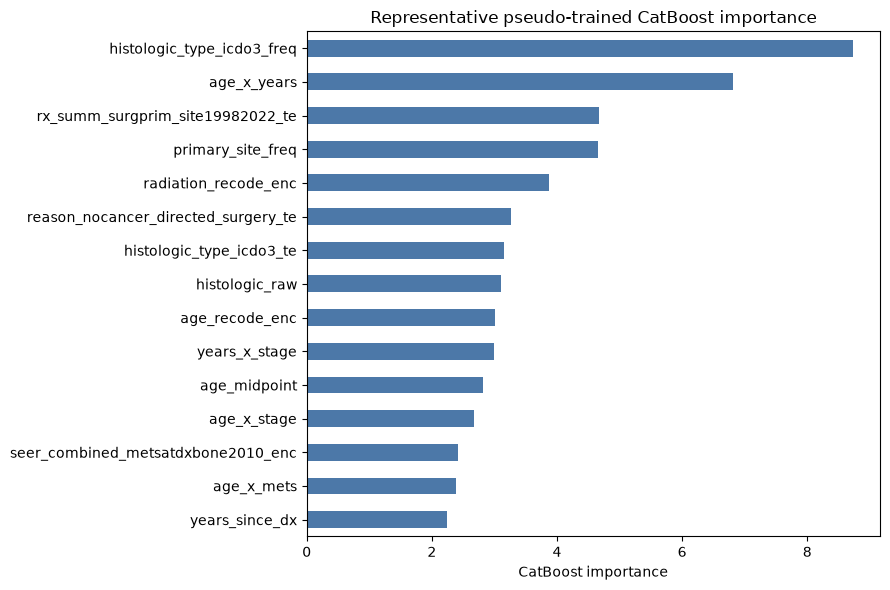

,age_band,patients,support_weighted_F1
2,55-59 years,1821,0.840213
1,50-54 years,789,0.845841
4,65-69 years,3851,0.847600
3,60-64 years,2925,0.858794
0,45-49 years,341,0.864631
5,70-74 years,4233,0.872716
6,75-79 years,4027,0.880514
7,80-84 years,2943,0.911149
8,85-89 years,1823,0.943309
9,90+ years,957,0.962568


In [8]:
def stable_top_k(probabilities, count):
    ranking = np.argsort(-np.asarray(probabilities), kind="mergesort")
    labels = np.zeros(len(ranking), dtype=np.int8)
    labels[ranking[:count]] = 1
    return labels

AUDIT_DIR = ROOT / "artifacts" / "submission10_notebook"
FRESH_TREE_PATH = AUDIT_DIR / "tree" / "probs_v6_final.npy"
FRESH_NN_PATH = AUDIT_DIR / "nn" / "probs_nn_fresh.npy"
FRESH_NN_OOF_PATH = AUDIT_DIR / "nn" / "oof_nn_fresh.npy"
for path in (FRESH_TREE_PATH, FRESH_NN_PATH, FRESH_NN_OOF_PATH):
    if not path.is_file():
        raise FileNotFoundError(f"Fresh training output missing: {path}")

fresh_tree_probability = np.load(FRESH_TREE_PATH, allow_pickle=False)
fresh_nn_probability = np.load(FRESH_NN_PATH, allow_pickle=False)
fresh_nn_oof = np.load(FRESH_NN_OOF_PATH, allow_pickle=False)
assert fresh_tree_probability.shape == fresh_nn_probability.shape == (len(test),)
assert fresh_nn_oof.shape == (len(train),)

fresh_blend_probability = 0.80 * fresh_tree_probability + 0.20 * fresh_nn_probability
fresh_is_dead = stable_top_k(fresh_blend_probability, DEAD_COUNT).astype(bool)
fresh_submission = pd.DataFrame({
    "patient_id": test["patient_id"].to_numpy(),
    "vital_status": np.where(fresh_is_dead, "Dead", "Alive"),
})
FRESH_SUBMISSION_PATH = AUDIT_DIR / "submission_fresh_retrain.csv"
fresh_submission.to_csv(FRESH_SUBMISSION_PATH, index=False, lineterminator="\n")

oof_count = round(0.845 * len(train))
fresh_oof_blend = 0.80 * oof_blend + 0.20 * fresh_nn_oof
fresh_oof_labels = stable_top_k(fresh_oof_blend, oof_count)
fresh_weighted_f1 = f1_score(
    y_binary, fresh_oof_labels, average="weighted", zero_division=0
)
fresh_dead_class_f1 = f1_score(
    y_binary, fresh_oof_labels, average="binary", zero_division=0
)
fresh_auc = roc_auc_score(y_binary, fresh_oof_blend)

fresh_vs_historical_changes = int(np.sum(fresh_is_dead != is_dead))
fresh_audit = pd.Series({
    "fresh_tree_probability_sha256": sha256(FRESH_TREE_PATH),
    "fresh_nn_probability_sha256": sha256(FRESH_NN_PATH),
    "fresh_submission_sha256": sha256(FRESH_SUBMISSION_PATH),
    "fresh_vs_historical_label_changes": fresh_vs_historical_changes,
    "fresh_OOF_support_weighted_F1": fresh_weighted_f1,
    "fresh_OOF_Dead_class_F1": fresh_dead_class_f1,
    "fresh_OOF_ROC_AUC": fresh_auc,
    "saved_fresh_NN_checkpoints": len(NN_CHECKPOINTS),
})
display(fresh_audit.to_frame("value"))

assert len(NN_CHECKPOINTS) == 5
fresh_tree_exact = sha256(FRESH_TREE_PATH) == EXPECTED_V6_SHA256
print("Fresh tree byte match:", "PASS" if fresh_tree_exact else "ENVIRONMENT DRIFT")
if not fresh_tree_exact:
    print(
        "The fresh tree probabilities differ at byte level, which can occur "
        "across library, operating-system, and hardware versions. The exact "
        "historical Submission 10 replay above is unaffected."
    )

# Representative importance from the retained pseudo-trained v4 CatBoost
# component. This is a component diagnostic, not a causal interpretation.
representative_names = list(X_train_base.columns) + [
    f"{column}_te" for column in te_cols
]
if hasattr(m, "get_feature_importance"):
    representative_values = np.asarray(m.get_feature_importance(), dtype=float)
    if len(representative_values) == len(representative_names):
        importance = (
            pd.DataFrame({"feature": representative_names, "importance": representative_values})
            .sort_values("importance", ascending=False)
            .head(15)
            .sort_values("importance")
        )
        ax = importance.plot.barh(
            x="feature", y="importance", legend=False, figsize=(9, 6), color="#4C78A8"
        )
        ax.set_title("Representative pseudo-trained CatBoost importance")
        ax.set_xlabel("CatBoost importance")
        ax.set_ylabel("")
        plt.tight_layout()
        plt.show()

age_rows = []
age_values = train["age_recode"].fillna("Missing").astype(str)
for age_band, indices in age_values.groupby(age_values).groups.items():
    indices = np.asarray(list(indices))
    if len(indices) < 200:
        continue
    age_rows.append({
        "age_band": age_band,
        "patients": len(indices),
        "support_weighted_F1": f1_score(
            y_binary[indices], fresh_oof_labels[indices],
            average="weighted", zero_division=0,
        ),
    })
display(pd.DataFrame(age_rows).sort_values("support_weighted_F1"))


## 10. Results and limitations

Running this notebook regenerates the exact historical Submission 10 CSV. An
identical prediction file receives the same score when evaluated against the
same Kaggle labels.

The notebook also performs EDA, feature engineering, full Submission 6
training, five-fold NN training with newly saved checkpoints, OOF screening,
feature-importance inspection, and an age-band audit. The fresh model output is
kept under `artifacts/submission10_notebook/` and never replaces the exact
historical replay written to `submission.csv`.

The replay establishes the provenance of the scored predictions, blend, and
decision rule. It does not establish that the fresh neural-network run is the
unavailable historical fold state. Exact historical NN-training identity would
require the original checkpoints and runtime state; the notebook reports the
fresh-versus-historical label difference rather than hiding it.

No AutoML pipeline generator, external data, manual test labels, or row-level
leaderboard probing is used.
